In [76]:
!pip install pandas numpy matplotlib seaborn jieba scikit-learn wordcloud joblib

In [77]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set Chinese font for matplotlib
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Load the dataset
def load_data(file_path):
    """Load and explore the dataset"""
    excel_file = pd.ExcelFile(file_path)
    all_sheets_data = {}
    
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        all_sheets_data[sheet_name] = df
    
    return all_sheets_data

# Sentiment keywords definition
def define_sentiment_keywords():
    """Define Chinese keywords for sentiment analysis"""
    positive_keywords = [
        '好', '棒', '赞', '喜欢', '满意', '推荐', '不错', '很好', '优秀', '完美', '惊喜', '感动', '放心', '友好',
        '清晰', '高清', '可爱', '小巧', '漂亮', '美观', '实用', '方便', '快捷', '迅速', '正品', '信赖', '值得',
        '超值', '划算', '优惠', '性价比', '厉害', '专业', '强大', '稳定', '顺畅', '流畅', '舒服', '舒适'
    ]
    
    negative_keywords = [
        '差', '坏', '烂', '失望', '问题', '糟糕', '垃圾', '后悔', '缺陷', '不足', '麻烦', '慢', '卡顿', '延迟',
        '发热', '故障', '损坏', '破损', '错', '误', '假货', '昂贵', '贵', '不值', '浪费', '难用', '复杂', '笨重',
        '粗糙', '模糊', '暗淡', '失真', '噪音', '异响', '震动', '过热'
    ]
    
    return positive_keywords, negative_keywords

# Rule-based sentiment classifier
def rule_based_sentiment_classification(text, positive_keywords, negative_keywords):
    """Classify sentiment based on keyword counting"""
    pos_count = sum(1 for word in positive_keywords if word in text)
    neg_count = sum(1 for word in negative_keywords if word in text)
    
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

# Additional metrics calculation
def calculate_additional_scores(text, referral_keywords, community_keywords, discussion_keywords):
    """Calculate referral, community, and discussion scores"""
    referral_score = sum(1 for word in referral_keywords if word in text) / len(referral_keywords)
    community_score = sum(1 for word in community_keywords if word in text) / len(community_keywords)
    discussion_score = sum(1 for word in discussion_keywords if word in text) / len(discussion_keywords)
    return referral_score, community_score, discussion_score

# Main sentiment analysis function
def perform_sentiment_analysis(file_path):
    """Main function to perform comprehensive sentiment analysis"""
    # Load data
    all_sheets_data = load_data(file_path)
    df = all_sheets_data['Sheet1']
    
    # Define keywords
    positive_keywords, negative_keywords = define_sentiment_keywords()
    
    # Rule-based sentiment classification
    df['sentiment_label'] = df['评论内容'].apply(
        lambda x: rule_based_sentiment_classification(x, positive_keywords, negative_keywords)
    )
    
    # Prepare data for ML model
    vectorizer = TfidfVectorizer(max_features=5000, stop_words=None, ngram_range=(1, 2))
    X = vectorizer.fit_transform(df['评论内容'])
    y = df['sentiment_label']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train Naive Bayes model
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    
    # Make predictions on all data
    all_predictions = nb_model.predict(X)
    all_probabilities = nb_model.predict_proba(X)
    
    # Get class labels
    classes = nb_model.classes_
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}
    
    # Add prediction results to dataframe
    df['positive_score'] = all_probabilities[:, class_to_index.get('positive', 0)]
    df['neutral_score'] = all_probabilities[:, class_to_index.get('neutral', 0)]
    df['negative_score'] = all_probabilities[:, class_to_index.get('negative', 0)]
    df['predicted_sentiment'] = all_predictions
    
    # Define keywords for additional metrics
    referral_keywords = ['推荐', '分享', '朋友', '家人', '同事', '推荐给', '安利', '种草', '告诉']
    community_keywords = ['社区', '论坛', '交流', '讨论', '群', '圈子', '社群', '互动', '参与']
    discussion_keywords = ['讨论', '交流', '请教', '咨询', '问答', '问题', '求助', '探讨', '研究']
    
    # Calculate additional scores
    df[['referral_score', 'community_score', 'discussion_score']] = df['评论内容'].apply(
        lambda x: pd.Series(calculate_additional_scores(
            x, referral_keywords, community_keywords, discussion_keywords
        ))
    )
    
    return df, nb_model, vectorizer

# Visualization functions
def create_visualizations(df, brand_scores):
    """Create visualizations for sentiment analysis results"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Overall sentiment distribution
    sentiment_counts = df['predicted_sentiment'].value_counts()
    axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 0].set_title('Overall Sentiment Distribution')
    axes[0, 0].set_ylabel('Number of Comments')
    
    # 2. Average sentiment scores by brand
    brands = brand_scores.index
    x_pos = range(len(brands))
    width = 0.25
    
    axes[0, 1].bar([x - width for x in x_pos], brand_scores['positive_score'], 
                   width, label='Positive', color='#1f77b4')
    axes[0, 1].bar(x_pos, brand_scores['neutral_score'], 
                   width, label='Neutral', color='#ff7f0e')
    axes[0, 1].bar([x + width for x in x_pos], brand_scores['negative_score'], 
                   width, label='Negative', color='#2ca02c')
    axes[0, 1].set_title('Average Sentiment Scores by Brand')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(brands)
    axes[0, 1].legend()
    
    # 3. Additional scores by brand
    axes[0, 2].bar([x - width for x in x_pos], brand_scores['referral_score'], 
                   width, label='Referral', color='#d62728')
    axes[0, 2].bar(x_pos, brand_scores['community_score'], 
                   width, label='Community', color='#9467bd')
    axes[0, 2].bar([x + width for x in x_pos], brand_scores['discussion_score'], 
                   width, label='Discussion', color='#8c564b')
    axes[0, 2].set_title('Additional Scores by Brand')
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels(brands)
    axes[0, 2].legend()
    
    # 4. Sentiment score distribution histogram
    axes[1, 0].hist(df['positive_score'], bins=30, alpha=0.7, 
                    color='#1f77b4', label='Positive')
    axes[1, 0].hist(df['negative_score'], bins=30, alpha=0.7, 
                    color='#2ca02c', label='Negative')
    axes[1, 0].set_title('Distribution of Sentiment Scores')
    axes[1, 0].set_xlabel('Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    
    # 5. Referral score distribution
    axes[1, 1].hist(df['referral_score'], bins=30, alpha=0.7, color='#d62728')
    axes[1, 1].set_title('Distribution of Referral Scores')
    axes[1, 1].set_xlabel('Score')
    axes[1, 1].set_ylabel('Frequency')
    
    # 6. Community vs discussion scores
    axes[1, 2].scatter(df['community_score'], df['discussion_score'], 
                       alpha=0.5, color='#9467bd')
    axes[1, 2].set_title('Community vs Discussion Scores')
    axes[1, 2].set_xlabel('Community Score')
    axes[1, 2].set_ylabel('Discussion Score')
    
    plt.tight_layout()
    plt.savefig('sentiment_analysis_results.png', dpi=300, bbox_inches='tight')
    plt.close()

# Main execution
if __name__ == "__main__":
    # File path
    file_path = 'AllCameras_Cleaned.xlsx'
    
    # Perform sentiment analysis
    df, nb_model, vectorizer = perform_sentiment_analysis(file_path)
    
    # Analyze sentiment by brand
    brand_scores = df.groupby('品牌')[['positive_score', 'neutral_score', 'negative_score', 
                                      'referral_score', 'community_score', 'discussion_score']].mean()
    
    # Create visualizations
    create_visualizations(df, brand_scores)
    
    # Save results to Excel
    output_columns = ['用户ID', '时间', '商品规格', '评论内容', '页面标题', '品牌', 
                      'predicted_sentiment', 'positive_score', 'neutral_score', 'negative_score',
                      'referral_score', 'community_score', 'discussion_score']
    
    df_output = df[output_columns]
    output_file = 'camera_reviews_sentiment_analysis.xlsx'
    df_output.to_excel(output_file, index=False)
    
    # Print summary statistics
    print("="*50)
    print("SENTIMENT ANALYSIS RESULTS SUMMARY")
    print("="*50)
    print(f"Total Comments Analyzed: {len(df)}")
    print(f"Overall Positive Score: {df['positive_score'].mean():.4f}")
    print(f"Overall Negative Score: {df['negative_score'].mean():.4f}")
    print(f"Overall Referral Score: {df['referral_score'].mean():.4f}")
    print("\nResults saved to:", output_file)
    print("Visualizations saved to: sentiment_analysis_results.png")

SENTIMENT ANALYSIS RESULTS SUMMARY
Total Comments Analyzed: 4170
Overall Positive Score: 0.9242
Overall Negative Score: 0.0088
Overall Referral Score: 0.0165

Results saved to: camera_reviews_sentiment_analysis.xlsx
Visualizations saved to: sentiment_analysis_results.png


Performing word segmentation...
Preparing to vectorize 4170 reviews with TF-IDF
Top keywords plot saved as: top_keywords_tfidf.png
Keyword frequency plot saved as: keyword_frequency.png
TF-IDF heatmap saved as: tfidf_heatmap.png
Sentiment comparison plot saved as: sentiment_keyword_comparison.png


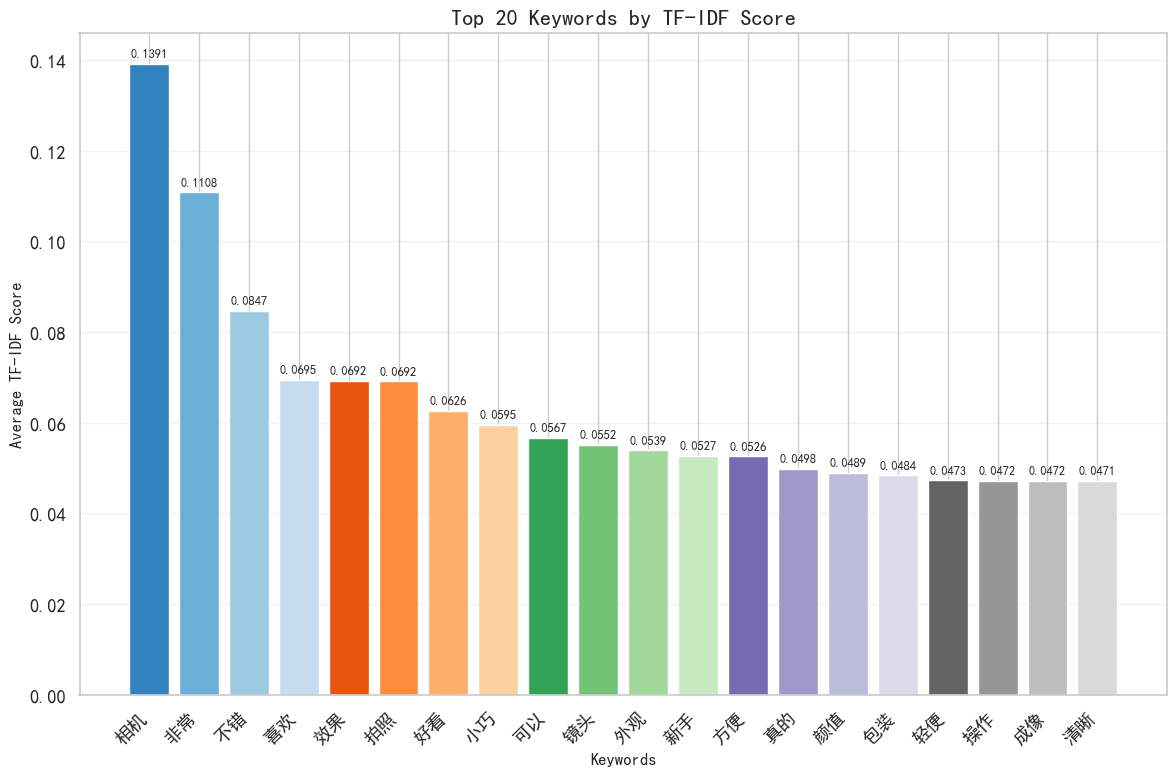

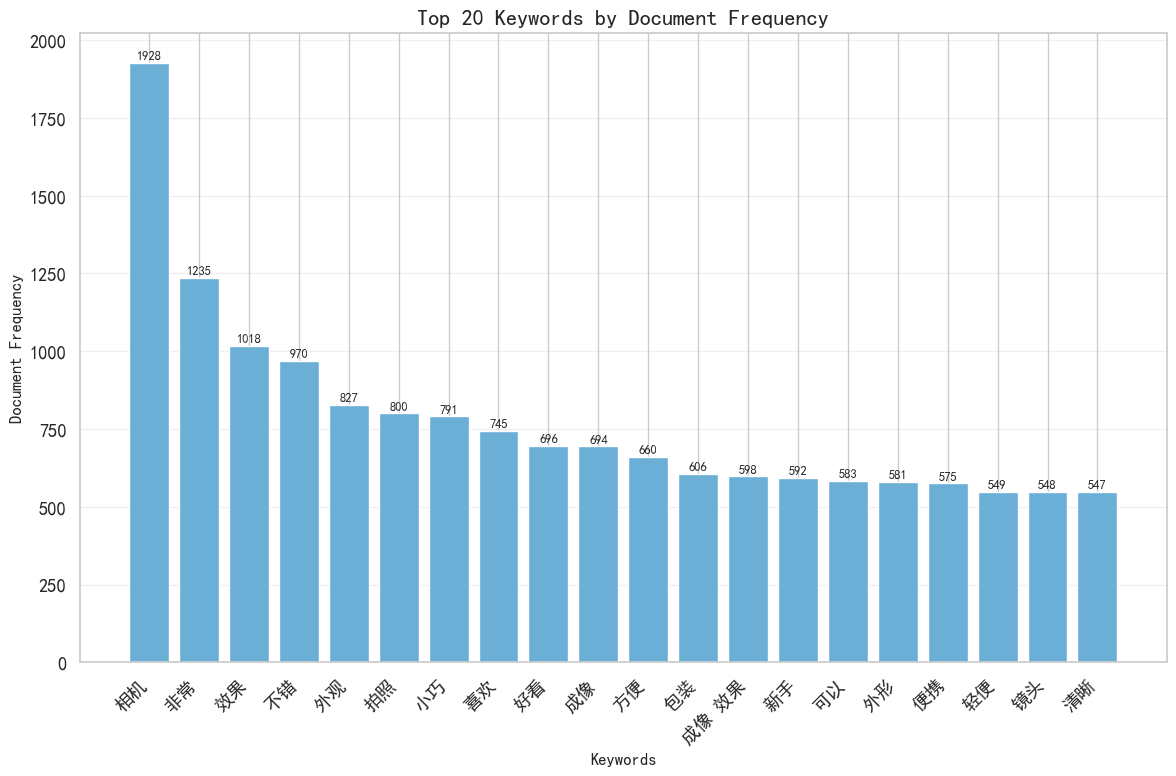

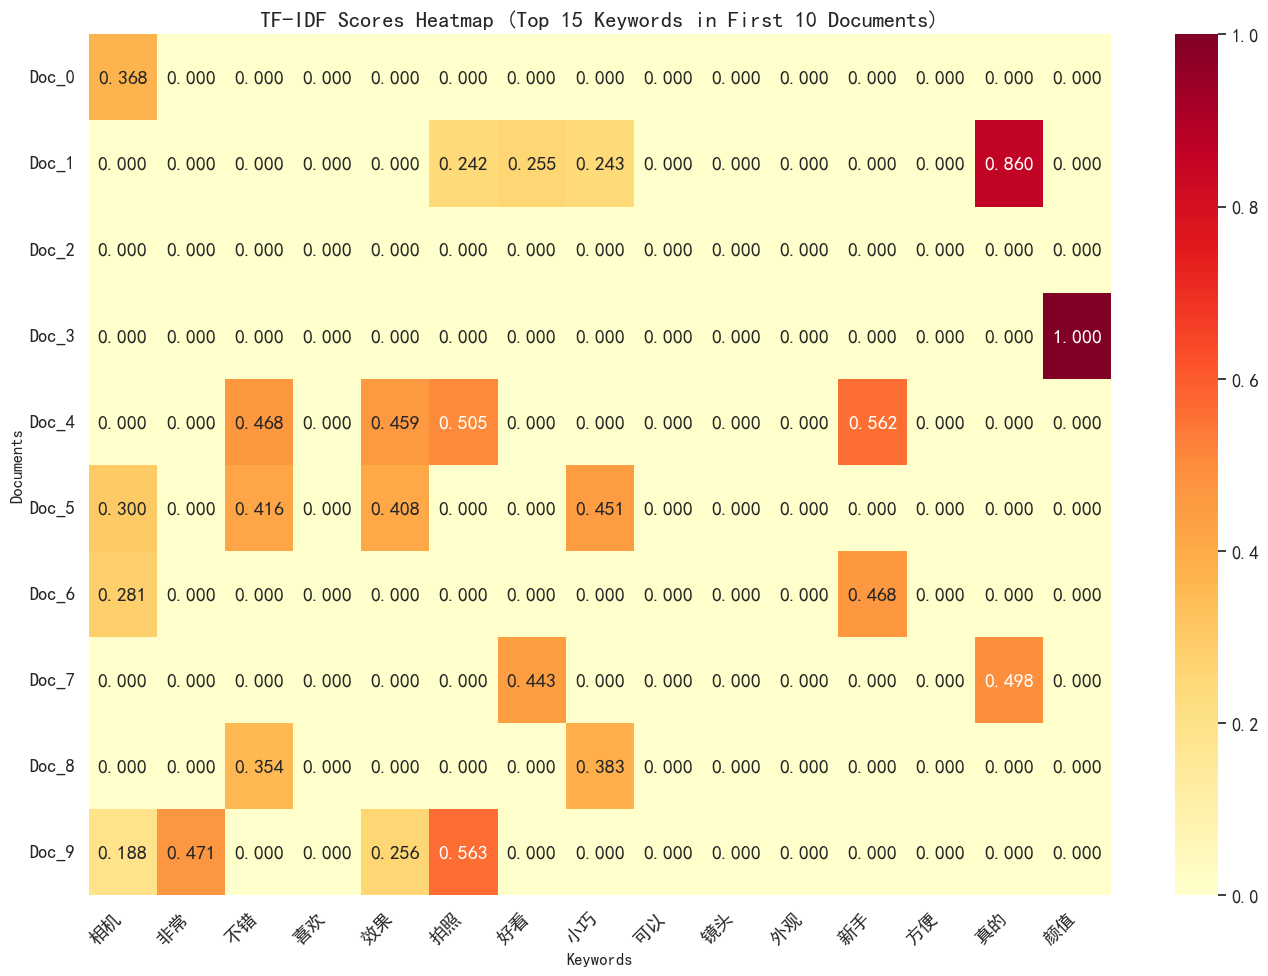

<Figure size 1400x800 with 0 Axes>

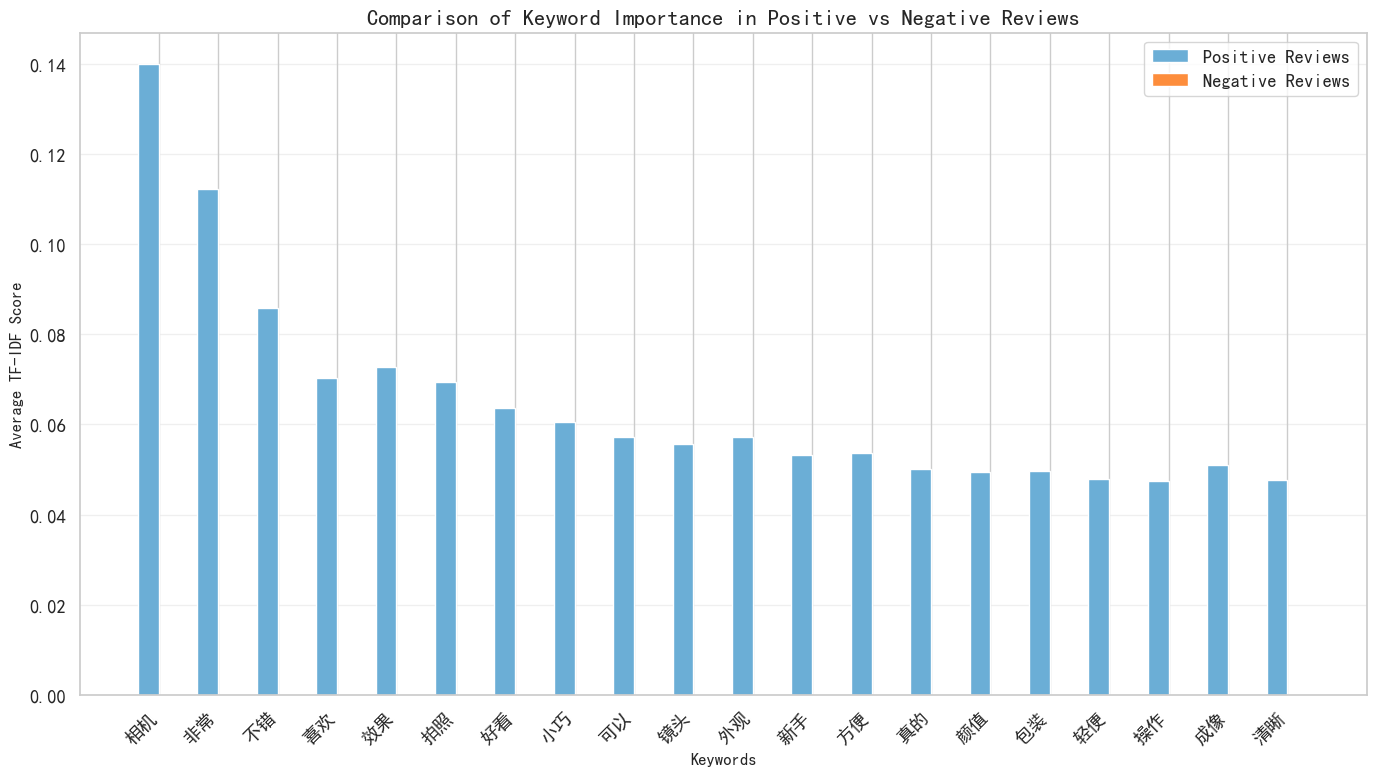

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set Chinese font
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Load data
df = pd.read_excel('camera_reviews_sentiment_analysis.xlsx')

# Text preprocessing
def preprocess_text(text):
    text = re.sub(r'[^\u4e00-\u9fa5]', '', str(text))
    return text

df['processed_review'] = df['评论内容'].apply(preprocess_text)

# Chinese word segmentation
def chinese_tokenizer(text):
    words = jieba.cut(text)
    words = [word for word in words if len(word) >= 2]
    return ' '.join(words)

print("Performing word segmentation...")
df['segmented_review'] = df['processed_review'].apply(chinese_tokenizer)

# Apply TF-IDF vectorization
reviews = df['segmented_review'].tolist()
print(f"Preparing to vectorize {len(reviews)} reviews with TF-IDF")

tfidf_vectorizer = TfidfVectorizer(
    max_features=50,   # Extract top 50 features
    min_df=5,          # Words must appear in at least 5 documents
    max_df=0.7,        # Words can appear in at most 70% of documents
    ngram_range=(1, 2) # Include 1-2 word combinations
)

tfidf_matrix = tfidf_vectorizer.fit_transform(reviews)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate average TF-IDF scores
avg_tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Get top 20 keywords and their TF-IDF scores
top_indices = avg_tfidf_scores.argsort()[::-1][:20]
top_words = [feature_names[i] for i in top_indices]
top_scores = [avg_tfidf_scores[i] for i in top_indices]

# 1. Plot Top 20 keywords by TF-IDF score
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(top_words)), top_scores, color=plt.cm.tab20c.colors)
plt.title('Top 20 Keywords by TF-IDF Score', fontsize=16)
plt.xlabel('Keywords', fontsize=12)
plt.ylabel('Average TF-IDF Score', fontsize=12)
plt.xticks(range(len(top_words)), top_words, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (word, score) in enumerate(zip(top_words, top_scores)):
    plt.text(i, score + 0.001, f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
top_keywords_plot = 'top_keywords_tfidf.png'
plt.savefig(top_keywords_plot, dpi=300, bbox_inches='tight')
print(f"Top keywords plot saved as: {top_keywords_plot}")

# 2. Plot keyword frequency distribution
# Calculate document frequency for each word
keyword_counts = {}
for i, word in enumerate(feature_names):
    count = (tfidf_matrix[:, i] > 0).sum()
    keyword_counts[word] = count

# Get top 20 most frequent words
sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)[:20]
freq_words = [item[0] for item in sorted_keywords]
freq_counts = [item[1] for item in sorted_keywords]

plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(freq_words)), freq_counts, color=plt.cm.tab20c(1))
plt.title('Top 20 Keywords by Document Frequency', fontsize=16)
plt.xlabel('Keywords', fontsize=12)
plt.ylabel('Document Frequency', fontsize=12)
plt.xticks(range(len(freq_words)), freq_words, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (word, count) in enumerate(zip(freq_words, freq_counts)):
    plt.text(i, count + 5, f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
keyword_frequency_plot = 'keyword_frequency.png'
plt.savefig(keyword_frequency_plot, dpi=300, bbox_inches='tight')
print(f"Keyword frequency plot saved as: {keyword_frequency_plot}")

# 3. Plot TF-IDF heatmap (first 10 documents and top 15 keywords)
plt.figure(figsize=(14, 10))
# Get indices of top 15 keywords
top15_indices = avg_tfidf_scores.argsort()[::-1][:15]
top15_words = [feature_names[i] for i in top15_indices]

# Build heatmap data
heatmap_data = []
for doc_idx in range(min(10, tfidf_matrix.shape[0])):  # First 10 documents
    row = []
    for word_idx in top15_indices:
        row.append(tfidf_matrix[doc_idx, word_idx])
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, 
                         columns=top15_words,
                         index=[f'Doc_{i}' for i in range(len(heatmap_data))])

sns.heatmap(heatmap_df, annot=True, cmap='YlOrRd', fmt='.3f', cbar=True)
plt.title('TF-IDF Scores Heatmap (Top 15 Keywords in First 10 Documents)', fontsize=16)
plt.xlabel('Keywords', fontsize=12)
plt.ylabel('Documents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
tfidf_heatmap = 'tfidf_heatmap.png'
plt.savefig(tfidf_heatmap, dpi=300, bbox_inches='tight')
print(f"TF-IDF heatmap saved as: {tfidf_heatmap}")

# 4. Compare keyword importance in positive vs negative reviews
# Get positive and negative review samples
positive_reviews = df[df['predicted_sentiment'] == 'positive']['segmented_review'].tolist()
negative_reviews = df[df['predicted_sentiment'] == 'negative']['segmented_review'].tolist()

# Apply TF-IDF to positive reviews
if len(positive_reviews) > 0:
    pos_tfidf_vectorizer = TfidfVectorizer(vocabulary=feature_names)
    pos_tfidf_matrix = pos_tfidf_vectorizer.fit_transform(positive_reviews)
    pos_avg_scores = np.asarray(pos_tfidf_matrix.mean(axis=0)).flatten()
else:
    pos_avg_scores = np.zeros(len(feature_names))

# Apply TF-IDF to negative reviews
if len(negative_reviews) > 0:
    neg_tfidf_vectorizer = TfidfVectorizer(vocabulary=feature_names)
    neg_tfidf_matrix = neg_tfidf_vectorizer.fit_transform(negative_reviews)
    neg_avg_scores = np.asarray(neg_tfidf_matrix.mean(axis=0)).flatten()
else:
    neg_avg_scores = np.zeros(len(feature_names))

# Plot comparison of keyword importance in positive vs negative reviews
plt.figure(figsize=(14, 8))
x = np.arange(len(top_words))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, [pos_avg_scores[list(feature_names).index(word)] for word in top_words], 
               width, label='Positive Reviews', color=plt.cm.tab20c(1))
bars2 = ax.bar(x + width/2, [neg_avg_scores[list(feature_names).index(word)] for word in top_words], 
               width, label='Negative Reviews', color=plt.cm.tab20c(5))

ax.set_xlabel('Keywords', fontsize=12)
ax.set_ylabel('Average TF-IDF Score', fontsize=12)
ax.set_title('Comparison of Keyword Importance in Positive vs Negative Reviews', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(top_words, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
sentiment_comparison_plot = 'sentiment_keyword_comparison.png'
plt.savefig(sentiment_comparison_plot, dpi=300, bbox_inches='tight')
print(f"Sentiment comparison plot saved as: {sentiment_comparison_plot}")

Loading and exploring data...
Data shape: (4170, 13)
Total reviews: 4170

Column names:
1. 用户ID
2. 时间
3. 商品规格
4. 评论内容
5. 页面标题
6. 品牌
7. predicted_sentiment
8. positive_score
9. neutral_score
10. negative_score
11. referral_score
12. community_score
13. discussion_score

SCORE AGGREGATION ANALYSIS

1. SENTIMENT DISTRIBUTION:
   POSITIVE: 4167 reviews (99.9%)
   NEUTRAL: 3 reviews (0.1%)

2. EXPLICIT RECOMMENDATIONS:
   497 reviews explicitly recommend the product (11.9%)

3. DEEP DISCUSSION RATIO:
   282 reviews contain deep discussion (6.8%)

4. COMMUNITY PARTICIPATION:
   19 reviews show community participation (0.5%)

5. SCORE STATISTICS:
                   mean    std    min    50%    max
positive_score    0.924  0.069  0.403  0.942  0.999
neutral_score     0.067  0.062  0.001  0.052  0.549
negative_score    0.009  0.009  0.000  0.007  0.173
referral_score    0.016  0.050  0.000  0.000  0.444
community_score   0.001  0.007  0.000  0.000  0.111
discussion_score  0.008  0.029  0.000  0

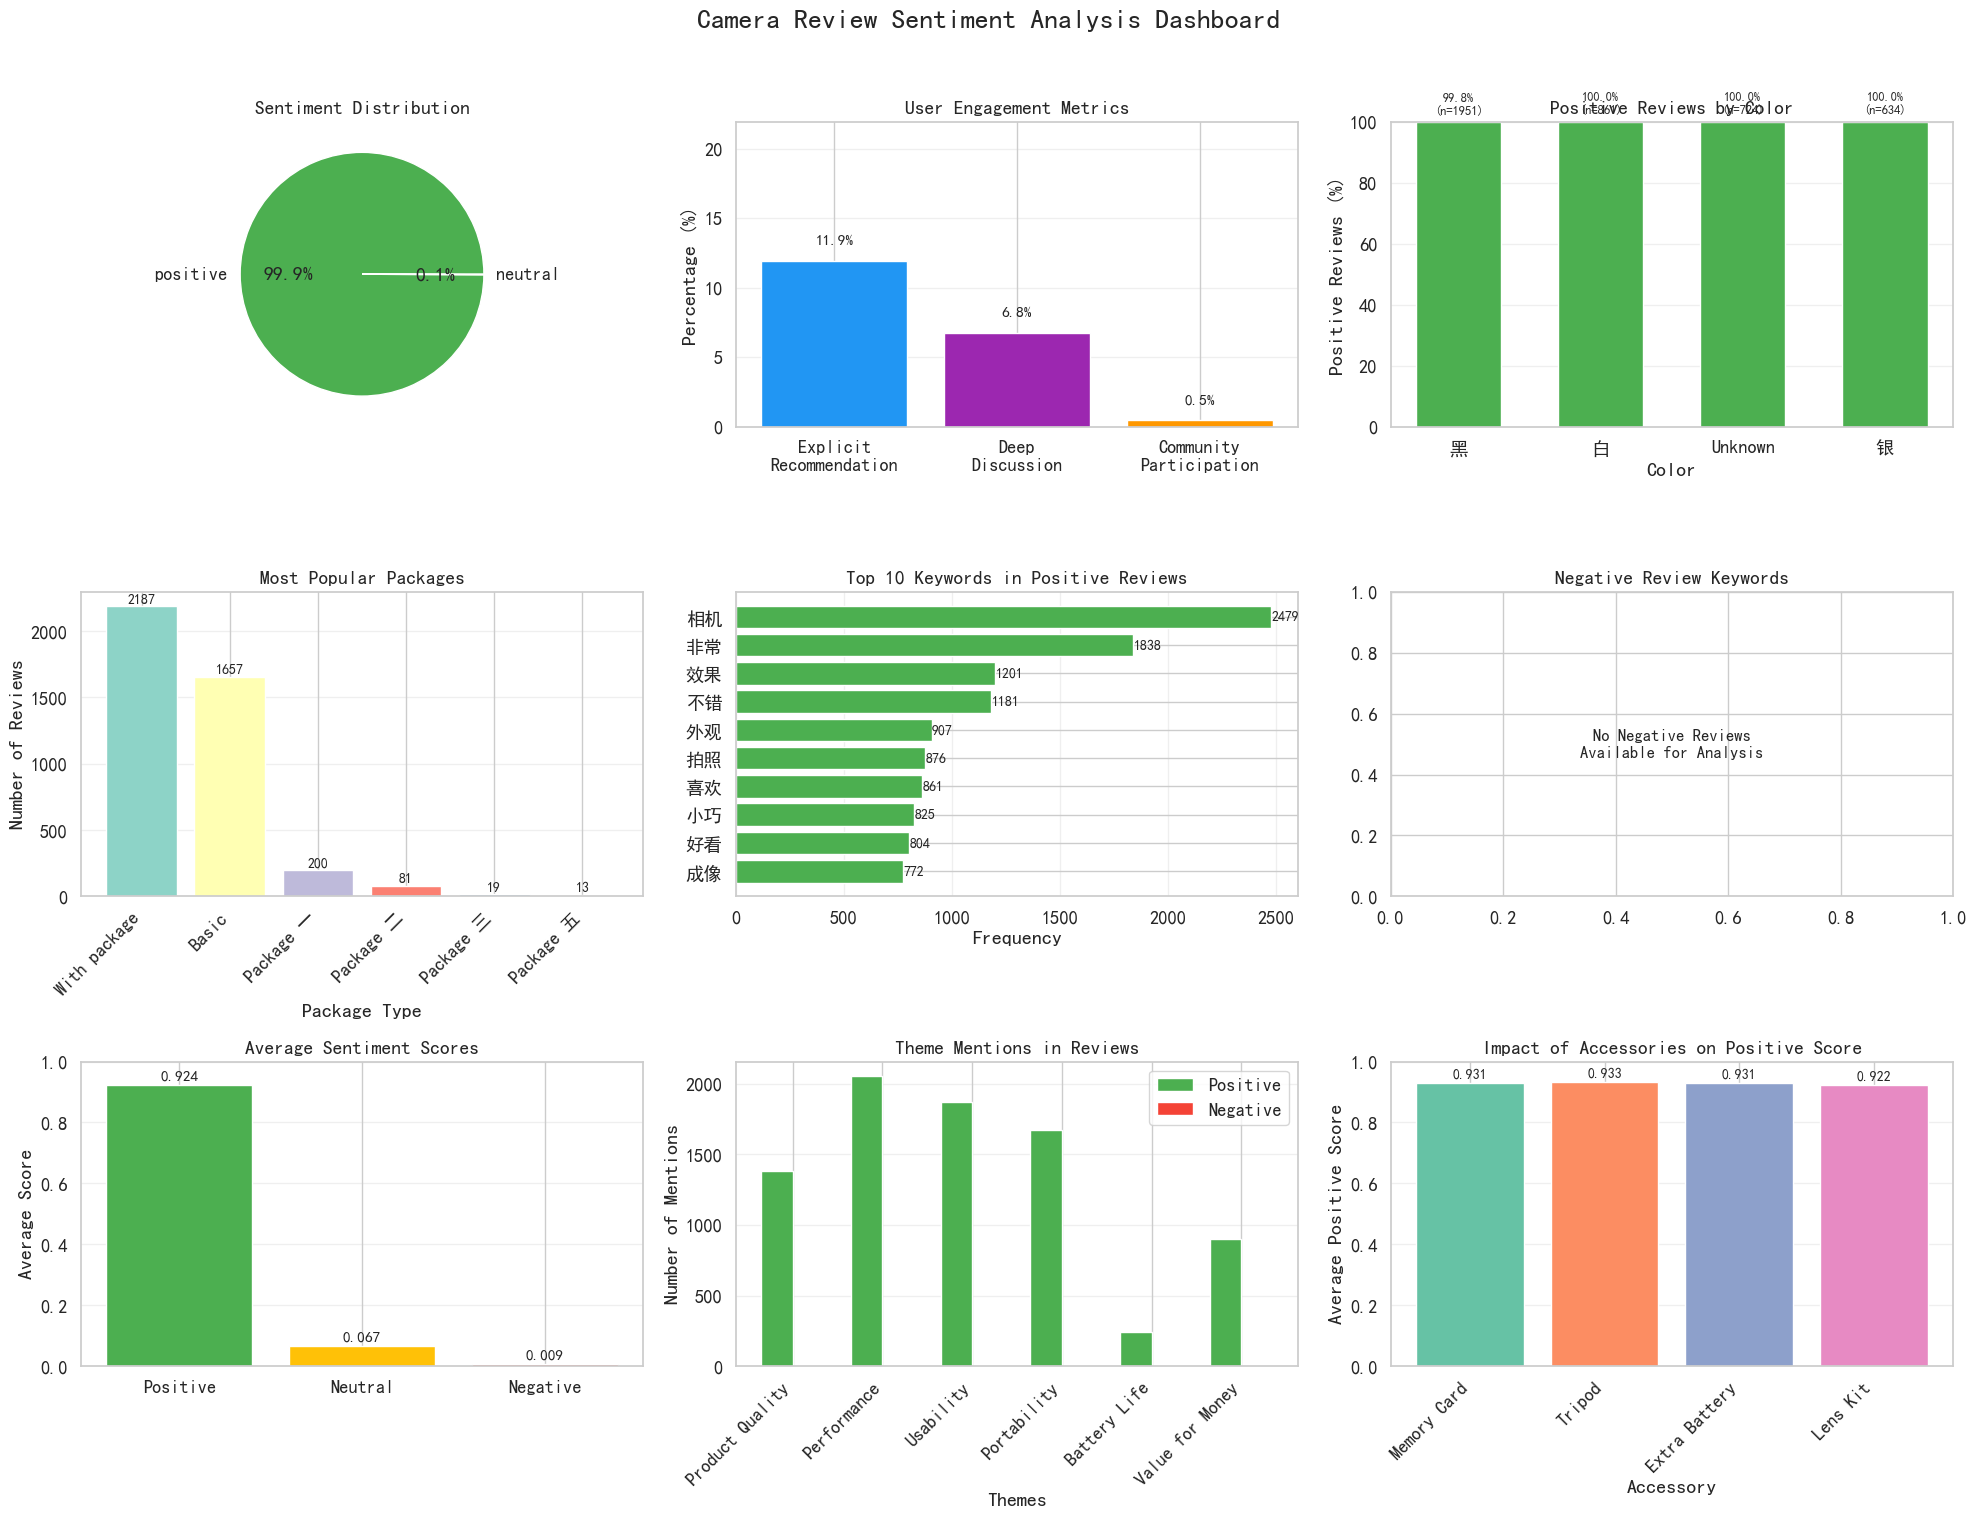


Analysis complete! Check the saved dashboard image for visual insights.


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import jieba
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set Chinese font for visualizations
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. Load and explore data
print("Loading and exploring data...")
df = pd.read_excel('camera_reviews_sentiment_analysis.xlsx')
print(f"Data shape: {df.shape}")
print(f"Total reviews: {len(df)}")
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

# 2. Score Aggregation Analysis
print("\n" + "="*80)
print("SCORE AGGREGATION ANALYSIS")
print("="*80)

# 2.1 Sentiment distribution statistics
sentiment_counts = df['predicted_sentiment'].value_counts()
sentiment_percent = df['predicted_sentiment'].value_counts(normalize=True) * 100

print(f"\n1. SENTIMENT DISTRIBUTION:")
for sentiment in sentiment_counts.index:
    print(f"   {sentiment.upper()}: {sentiment_counts[sentiment]} reviews ({sentiment_percent[sentiment]:.1f}%)")

# 2.2 Explicit recommendation ratio (referral_score > 0)
recommend_count = (df['referral_score'] > 0).sum()
recommend_percent = recommend_count / len(df) * 100
print(f"\n2. EXPLICIT RECOMMENDATIONS:")
print(f"   {recommend_count} reviews explicitly recommend the product ({recommend_percent:.1f}%)")

# 2.3 Deep discussion ratio (discussion_score > 0.1)
discussion_threshold = 0.1
deep_discussion_count = (df['discussion_score'] > discussion_threshold).sum()
deep_discussion_percent = deep_discussion_count / len(df) * 100
print(f"\n3. DEEP DISCUSSION RATIO:")
print(f"   {deep_discussion_count} reviews contain deep discussion ({deep_discussion_percent:.1f}%)")

# 2.4 Community participation ratio (community_score > 0)
community_count = (df['community_score'] > 0).sum()
community_percent = community_count / len(df) * 100
print(f"\n4. COMMUNITY PARTICIPATION:")
print(f"   {community_count} reviews show community participation ({community_percent:.1f}%)")

# 2.5 Score statistics
print(f"\n5. SCORE STATISTICS:")
score_columns = ['positive_score', 'neutral_score', 'negative_score', 
                 'referral_score', 'community_score', 'discussion_score']
score_stats = df[score_columns].describe().T[['mean', 'std', 'min', '50%', 'max']]
print(score_stats.round(3))

# 3. Dimensional Association Analysis
print("\n" + "="*80)
print("DIMENSIONAL ASSOCIATION ANALYSIS")
print("="*80)

# 3.1 Extract features from product specifications
def extract_spec_features(spec):
    """Extract key features from product specifications"""
    spec = str(spec)
    features = {
        'color': 'Unknown',
        'package': 'Unknown',
        'has_memory_card': False,
        'has_tripod': False,
        'has_battery': False,
        'has_lens': False,
        'is_basic': False
    }
    
    # Extract color
    colors = ['白色', '黑色', '银色', '灰色', '白', '黑', '银', '灰']
    for color in colors:
        if color in spec:
            features['color'] = color.replace('色', '')
            break
    
    # Extract package information
    if '套餐' in spec or '套机' in spec:
        package_match = re.search(r'套餐([一二三四五六七八九十1234567890]+)', spec)
        if package_match:
            features['package'] = f"Package {package_match.group(1)}"
        else:
            features['package'] = 'With package'
    elif '套机' in spec:
        features['package'] = 'With lens kit'
    else:
        features['package'] = 'Basic'
        features['is_basic'] = True
    
    # Check accessories
    if '内存卡' in spec or '存储卡' in spec or '高速卡' in spec or '128G' in spec or '256G' in spec or '卡' in spec:
        features['has_memory_card'] = True
    if '三脚架' in spec or '脚架' in spec:
        features['has_tripod'] = True
    if '电池' in spec or '双电池' in spec or '高容' in spec:
        features['has_battery'] = True
    if '镜头' in spec or '套机' in spec:
        features['has_lens'] = True
    
    return features

# Apply feature extraction
print("\nExtracting features from product specifications...")
spec_features = df['商品规格'].apply(extract_spec_features)
df_features = pd.DataFrame(spec_features.tolist())

# Merge features with original dataframe
df_combined = pd.concat([df, df_features], axis=1)

# 3.2 Color vs Sentiment Analysis
print("\n1. COLOR vs SENTIMENT ANALYSIS:")
color_sentiment = df_combined.groupby('color').agg({
    'positive_score': 'mean',
    'negative_score': 'mean',
    'predicted_sentiment': lambda x: (x == 'positive').mean() * 100,
    '用户ID': 'count'
}).round(3)

color_sentiment.columns = ['Avg_Positive_Score', 'Avg_Negative_Score', 
                           'Positive_Percent(%)', 'Review_Count']
color_sentiment = color_sentiment.sort_values('Review_Count', ascending=False)
print(color_sentiment)

# 3.3 Package vs Sentiment Analysis
print("\n2. PACKAGE vs SENTIMENT ANALYSIS:")
package_sentiment = df_combined.groupby('package').agg({
    'positive_score': 'mean',
    'negative_score': 'mean',
    'predicted_sentiment': lambda x: (x == 'positive').mean() * 100,
    '用户ID': 'count'
}).round(3)

package_sentiment.columns = ['Avg_Positive_Score', 'Avg_Negative_Score', 
                             'Positive_Percent(%)', 'Review_Count']
package_sentiment = package_sentiment.sort_values('Review_Count', ascending=False)
print(package_sentiment.head(10))

# 3.4 Accessory Impact Analysis
print("\n3. ACCESSORY IMPACT ANALYSIS:")
accessory_stats = pd.DataFrame()

for accessory_col in ['has_memory_card', 'has_tripod', 'has_battery', 'has_lens']:
    accessory_name = accessory_col.replace('has_', '').replace('_', ' ').title()
    
    stats = df_combined.groupby(accessory_col).agg({
        'positive_score': ['mean', 'std', 'count'],
        'predicted_sentiment': lambda x: (x == 'positive').mean() * 100
    }).round(3)
    
    # Flatten column names
    stats.columns = ['Avg_Positive', 'Std_Positive', 'Count', 'Positive_Percent']
    
    print(f"\n{accessory_name}:")
    print(stats)

# 4. Theme/Keyword Extraction
print("\n" + "="*80)
print("THEME/KEYWORD EXTRACTION")
print("="*80)

# 4.1 Text preprocessing functions
def preprocess_text(text):
    # Remove special characters and numbers, keep Chinese characters
    text = re.sub(r'[^\u4e00-\u9fa5]', '', str(text))
    return text

def chinese_tokenizer(text):
    # Use jieba for word segmentation
    words = jieba.cut(text)
    # Filter words with length less than 2
    words = [word for word in words if len(word) >= 2]
    return words

# Apply text preprocessing
print("\nPreprocessing text for keyword extraction...")
df_combined['processed_review'] = df_combined['评论内容'].apply(preprocess_text)

# Separate positive and negative reviews
positive_mask = df_combined['predicted_sentiment'] == 'positive'
negative_mask = df_combined['predicted_sentiment'] == 'negative'

positive_reviews = df_combined[positive_mask]['processed_review'].tolist()
negative_reviews = df_combined[negative_mask]['processed_review'].tolist()

print(f"Positive reviews: {len(positive_reviews)}")
print(f"Negative reviews: {len(negative_reviews)}")

# 4.2 Positive review keyword analysis
print("\n1. POSITIVE REVIEW ANALYSIS:")
if len(positive_reviews) > 0:
    # Tokenize all positive reviews
    positive_words = []
    for review in positive_reviews:
        positive_words.extend(chinese_tokenizer(review))
    
    # Count word frequencies
    positive_word_counts = Counter(positive_words)
    
    # Get top 20 most frequent words
    print("\nTop 20 Most Frequent Words in Positive Reviews:")
    positive_top_words = positive_word_counts.most_common(20)
    
    for i, (word, count) in enumerate(positive_top_words, 1):
        percentage = (count / len(positive_words)) * 100
        print(f"{i:2d}. {word:8s} Count: {count:4d} ({percentage:.2f}%)")
    
    # TF-IDF analysis for positive reviews
    print("\nTop 15 TF-IDF Keywords in Positive Reviews:")
    positive_reviews_text = [' '.join(chinese_tokenizer(review)) for review in positive_reviews]
    
    # Define stop words to exclude
    stop_words = ['不错', '可以', '非常', '很好', '很好用', '好用', '喜欢', '满意']
    
    tfidf_pos = TfidfVectorizer(
        max_features=15,
        stop_words=stop_words,
        min_df=2,
        max_df=0.8
    )
    
    tfidf_matrix_pos = tfidf_pos.fit_transform(positive_reviews_text)
    feature_names_pos = tfidf_pos.get_feature_names_out()
    
    # Calculate average TF-IDF scores
    avg_tfidf_scores_pos = np.asarray(tfidf_matrix_pos.mean(axis=0)).flatten()
    
    # Get top keywords
    top_indices_pos = avg_tfidf_scores_pos.argsort()[::-1][:15]
    
    for i, idx in enumerate(top_indices_pos, 1):
        print(f"{i:2d}. {feature_names_pos[idx]:10s} TF-IDF: {avg_tfidf_scores_pos[idx]:.4f}")

# 4.3 Negative review keyword analysis
print("\n2. NEGATIVE REVIEW ANALYSIS:")
if len(negative_reviews) > 0:
    # Tokenize all negative reviews
    negative_words = []
    for review in negative_reviews:
        negative_words.extend(chinese_tokenizer(review))
    
    # Count word frequencies
    negative_word_counts = Counter(negative_words)
    
    # Get top 20 most frequent words
    print("\nTop 20 Most Frequent Words in Negative Reviews:")
    negative_top_words = negative_word_counts.most_common(20)
    
    for i, (word, count) in enumerate(negative_top_words, 1):
        percentage = (count / len(negative_words)) * 100
        print(f"{i:2d}. {word:8s} Count: {count:4d} ({percentage:.2f}%)")
    
    # TF-IDF analysis for negative reviews
    print("\nTop 15 TF-IDF Keywords in Negative Reviews:")
    negative_reviews_text = [' '.join(chinese_tokenizer(review)) for review in negative_reviews]
    
    tfidf_neg = TfidfVectorizer(
        max_features=15,
        stop_words=stop_words if 'stop_words' in locals() else ['不好', '不行', '不满意'],
        min_df=2,
        max_df=0.8
    )
    
    tfidf_matrix_neg = tfidf_neg.fit_transform(negative_reviews_text)
    feature_names_neg = tfidf_neg.get_feature_names_out()
    
    # Calculate average TF-IDF scores
    avg_tfidf_scores_neg = np.asarray(tfidf_matrix_neg.mean(axis=0)).flatten()
    
    # Get top keywords
    top_indices_neg = avg_tfidf_scores_neg.argsort()[::-1][:15]
    
    for i, idx in enumerate(top_indices_neg, 1):
        print(f"{i:2d}. {feature_names_neg[idx]:10s} TF-IDF: {avg_tfidf_scores_neg[idx]:.4f}")
else:
    print("No negative reviews found in the dataset.")

# 4.4 Extract key themes/opinions
print("\n3. KEY THEMES/OPINIONS IDENTIFICATION:")

# Define theme categories and keywords
themes = {
    'Product Quality': ['质量', '品质', '做工', '材质', '手感', '外观', '设计'],
    'Performance': ['性能', '速度', '对焦', '画质', '清晰', '效果', '像素'],
    'Usability': ['操作', '使用', '方便', '简单', '容易', '新手', '友好'],
    'Portability': ['轻便', '小巧', '便携', '重量', '体积', '携带'],
    'Battery Life': ['电池', '续航', '充电', '电量', '待机'],
    'Value for Money': ['价格', '性价比', '划算', '优惠', '便宜', '贵', '值得'],
    'Delivery Service': ['发货', '物流', '快递', '包装', '送货', '速度'],
    'Customer Support': ['服务', '客服', '售后', '支持', '态度']
}

# Count theme mentions in positive and negative reviews
def count_theme_mentions(reviews, themes_dict):
    """Count how many times each theme is mentioned in reviews"""
    theme_counts = {theme: 0 for theme in themes_dict.keys()}
    
    for review in reviews:
        for theme, keywords in themes_dict.items():
            for keyword in keywords:
                if keyword in review:
                    theme_counts[theme] += 1
                    break  # Count each theme only once per review
    
    return theme_counts

# Count themes in positive reviews
if len(positive_reviews) > 0:
    pos_theme_counts = count_theme_mentions(positive_reviews, themes)
    print("\nThemes in Positive Reviews (mentions):")
    for theme, count in sorted(pos_theme_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            percentage = (count / len(positive_reviews)) * 100
            print(f"  {theme:20s}: {count:3d} reviews ({percentage:.1f}%)")

# Count themes in negative reviews
neg_theme_counts = {} 
if len(negative_reviews) > 0:
    neg_theme_counts = count_theme_mentions(negative_reviews, themes)
    print("\nThemes in Negative Reviews (mentions):")
    for theme, count in sorted(neg_theme_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            percentage = (count / len(negative_reviews)) * 100
            print(f"  {theme:20s}: {count:3d} reviews ({percentage:.1f}%)")

# 5. Create comprehensive visualizations
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Create visualization dashboard
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Camera Review Sentiment Analysis Dashboard', fontsize=20, fontweight='bold')

# 5.1 Sentiment Distribution (Pie Chart)
ax1 = plt.subplot(3, 3, 1)
colors = ['#4CAF50', '#FF9800', '#F44336']  # Green, Orange, Red
sentiment_counts.plot.pie(autopct='%1.1f%%', colors=colors, ax=ax1)
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

# 5.2 Engagement Metrics (Bar Chart)
ax2 = plt.subplot(3, 3, 2)
categories = ['Explicit\nRecommendation', 'Deep\nDiscussion', 'Community\nParticipation']
values = [recommend_percent, deep_discussion_percent, community_percent]
colors_engagement = ['#2196F3', '#9C27B0', '#FF9800']

bars = ax2.bar(range(len(categories)), values, color=colors_engagement)
ax2.set_title('User Engagement Metrics', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticks(range(len(categories)))
ax2.set_xticklabels(categories, rotation=0)
ax2.set_ylim(0, max(values) + 10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=11)

# 5.3 Color vs Positive Score
ax3 = plt.subplot(3, 3, 3)
colors_data = color_sentiment.head(5)  # Top 5 colors
x_pos = range(len(colors_data))
bar_width = 0.6

bars = ax3.bar(x_pos, colors_data['Positive_Percent(%)'], 
               width=bar_width, color='#4CAF50')
ax3.set_title('Positive Reviews by Color', fontsize=14, fontweight='bold')
ax3.set_xlabel('Color')
ax3.set_ylabel('Positive Reviews (%)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(colors_data.index, rotation=0)
ax3.set_ylim(0, 100)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(colors_data.iterrows()):
    ax3.text(i, row['Positive_Percent(%)'] + 2, 
             f"{row['Positive_Percent(%)']:.1f}%\n(n={int(row['Review_Count'])})", 
             ha='center', va='bottom', fontsize=9)

# 5.4 Package Popularity
ax4 = plt.subplot(3, 3, 4)
package_data = package_sentiment.head(6)  # Top 6 packages
x_pos = range(len(package_data))

bars = ax4.bar(x_pos, package_data['Review_Count'], 
               color=plt.cm.Set3(range(len(package_data))))
ax4.set_title('Most Popular Packages', fontsize=14, fontweight='bold')
ax4.set_xlabel('Package Type')
ax4.set_ylabel('Number of Reviews')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(package_data.index, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(package_data.iterrows()):
    ax4.text(i, row['Review_Count'] + 5, 
             f"{int(row['Review_Count'])}", 
             ha='center', va='bottom', fontsize=10)

# 5.5 Positive Review Keywords (Word Frequency)
ax5 = plt.subplot(3, 3, 5)
if len(positive_reviews) > 0 and 'positive_top_words' in locals():
    top_n = 10
    words = [word for word, _ in positive_top_words[:top_n]]
    counts = [count for _, count in positive_top_words[:top_n]]
    
    bars = ax5.barh(range(top_n), counts, color='#4CAF50')
    ax5.set_title(f'Top {top_n} Keywords in Positive Reviews', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Frequency')
    ax5.set_yticks(range(top_n))
    ax5.set_yticklabels(words)
    ax5.invert_yaxis()  # Highest at top
    ax5.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (word, count) in enumerate(zip(words, counts)):
        ax5.text(count + 2, i, f'{count}', va='center', fontsize=10)

# 5.6 Negative Review Keywords (if available)
ax6 = plt.subplot(3, 3, 6)
if len(negative_reviews) > 0 and 'negative_top_words' in locals():
    top_n = min(10, len(negative_top_words))
    words = [word for word, _ in negative_top_words[:top_n]]
    counts = [count for _, count in negative_top_words[:top_n]]
    
    bars = ax6.barh(range(top_n), counts, color='#F44336')
    ax6.set_title(f'Top {top_n} Keywords in Negative Reviews', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Frequency')
    ax6.set_yticks(range(top_n))
    ax6.set_yticklabels(words)
    ax6.invert_yaxis()  # Highest at top
    ax6.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (word, count) in enumerate(zip(words, counts)):
        ax6.text(count + 0.5, i, f'{count}', va='center', fontsize=10)
else:
    ax6.text(0.5, 0.5, 'No Negative Reviews\nAvailable for Analysis', 
             ha='center', va='center', fontsize=12, transform=ax6.transAxes)
    ax6.set_title('Negative Review Keywords', fontsize=14, fontweight='bold')

# 5.7 Score Distribution
ax7 = plt.subplot(3, 3, 7)
score_data = df[['positive_score', 'neutral_score', 'negative_score']].mean()
score_labels = ['Positive', 'Neutral', 'Negative']
colors_scores = ['#4CAF50', '#FFC107', '#F44336']

bars = ax7.bar(score_labels, score_data.values, color=colors_scores)
ax7.set_title('Average Sentiment Scores', fontsize=14, fontweight='bold')
ax7.set_ylabel('Average Score')
ax7.set_ylim(0, 1)
ax7.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars, score_data.values):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=11)

# 5.8 Theme Analysis
ax8 = plt.subplot(3, 3, 8)
if 'pos_theme_counts' in locals():
    themes_to_plot = []
    pos_counts = []
    neg_counts = []
    
    for theme in ['Product Quality', 'Performance', 'Usability', 'Portability', 
                  'Battery Life', 'Value for Money']:
        if theme in pos_theme_counts and pos_theme_counts[theme] > 0:
            themes_to_plot.append(theme)
            pos_counts.append(pos_theme_counts[theme])
            
            if theme in neg_theme_counts:
                neg_counts.append(neg_theme_counts[theme])
            else:
                neg_counts.append(0)
    
    if themes_to_plot:
        x = range(len(themes_to_plot))
        width = 0.35
        
        ax8.bar([i - width/2 for i in x], pos_counts, width, label='Positive', color='#4CAF50')
        ax8.bar([i + width/2 for i in x], neg_counts, width, label='Negative', color='#F44336')
        
        ax8.set_title('Theme Mentions in Reviews', fontsize=14, fontweight='bold')
        ax8.set_xlabel('Themes')
        ax8.set_ylabel('Number of Mentions')
        ax8.set_xticks(x)
        ax8.set_xticklabels(themes_to_plot, rotation=45, ha='right')
        ax8.legend()
        ax8.grid(axis='y', alpha=0.3)

# 5.9 Accessory Impact
ax9 = plt.subplot(3, 3, 9)
accessory_cols = ['has_memory_card', 'has_tripod', 'has_battery', 'has_lens']
accessory_names = ['Memory Card', 'Tripod', 'Extra Battery', 'Lens Kit']
avg_scores = []

for col in accessory_cols:
    if col in df_combined.columns:
        avg_score = df_combined[df_combined[col]]['positive_score'].mean()
        avg_scores.append(avg_score if not pd.isna(avg_score) else 0)
    else:
        avg_scores.append(0)

if avg_scores:
    x = range(len(accessory_names))
    bars = ax9.bar(x, avg_scores, color=plt.cm.Set2(range(len(accessory_names))))
    ax9.set_title('Impact of Accessories on Positive Score', fontsize=14, fontweight='bold')
    ax9.set_xlabel('Accessory')
    ax9.set_ylabel('Average Positive Score')
    ax9.set_xticks(x)
    ax9.set_xticklabels(accessory_names, rotation=45, ha='right')
    ax9.set_ylim(0, 1)
    ax9.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, score in enumerate(avg_scores):
        ax9.text(i, score + 0.01, f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('camera_reviews_analysis_dashboard.png', dpi=300, bbox_inches='tight')
print("Analysis dashboard saved as: camera_reviews_analysis_dashboard.png")

# 6. Generate Analysis Report
print("\n" + "="*80)
print("ANALYSIS REPORT SUMMARY")
print("="*80)

print("\n1. OVERALL SENTIMENT PROFILE:")
print(f"   • Total Reviews: {len(df):,}")
print(f"   • Positive: {sentiment_counts.get('positive', 0):,} ({sentiment_percent.get('positive', 0):.1f}%)")
print(f"   • Neutral: {sentiment_counts.get('neutral', 0):,} ({sentiment_percent.get('neutral', 0):.1f}%)")
print(f"   • Negative: {sentiment_counts.get('negative', 0):,} ({sentiment_percent.get('negative', 0):.1f}%)")

print("\n2. USER ENGAGEMENT METRICS:")
print(f"   • {recommend_percent:.1f}% of users explicitly recommend the product")
print(f"   • {deep_discussion_percent:.1f}% of reviews contain detailed discussions")
print(f"   • {community_percent:.1f}% of reviews show community participation")

print("\n3. KEY FINDINGS BY DIMENSION:")

# Color analysis
if not color_sentiment.empty:
    best_color = color_sentiment['Positive_Percent(%)'].idxmax()
    best_color_score = color_sentiment.loc[best_color, 'Positive_Percent(%)']
    print(f"   • Most Popular Color: {best_color} ({best_color_score:.1f}% positive reviews)")
    print(f"     - Total reviews for {best_color}: {int(color_sentiment.loc[best_color, 'Review_Count'])}")

# Package analysis
if not package_sentiment.empty:
    most_popular_package = package_sentiment['Review_Count'].idxmax()
    most_popular_count = package_sentiment.loc[most_popular_package, 'Review_Count']
    print(f"   • Most Popular Package: {most_popular_package} ({most_popular_count} reviews)")

# Positive review themes
if 'positive_top_words' in locals():
    print(f"\n4. POSITIVE REVIEW THEMES (Top 5 Keywords):")
    for i, (word, count) in enumerate(positive_top_words[:5], 1):
        print(f"   {i}. {word}")

# Negative review themes
if 'negative_top_words' in locals() and negative_top_words:
    print(f"\n5. NEGATIVE REVIEW THEMES (Top 5 Keywords):")
    for i, (word, count) in enumerate(negative_top_words[:5], 1):
        print(f"   {i}. {word}")

# Accessory impact
print(f"\n6. ACCESSORY IMPACT ANALYSIS:")
for i, (col, name) in enumerate(zip(accessory_cols, accessory_names)):
    if col in df_combined.columns:
        with_accessory = df_combined[df_combined[col]]['positive_score'].mean()
        without_accessory = df_combined[~df_combined[col]]['positive_score'].mean()
        
        if not pd.isna(with_accessory) and not pd.isna(without_accessory):
            diff = with_accessory - without_accessory
            impact = "positive" if diff > 0 else "negative"
            print(f"   • {name}: {diff:+.3f} impact on satisfaction ({impact})")

print("\n7. RECOMMENDATIONS:")
print("   • Focus marketing on the most popular color configurations")
print("   • Consider including popular accessories in standard packages")
print("   • Address concerns related to the most common negative themes")
print("   • Leverage positive keywords in marketing materials")
print("   • Monitor and respond to reviews with deep discussions")

plt.show()
print("\nAnalysis complete! Check the saved dashboard image for visual insights.")